# COMFORT Eval — Test01 & Test02 Analysis

- **Test01** (`test01_aligned_first`): paired-image MCQ, Image 1 = aligned perspective (`cam_back`), Image 2 = another viewpoint. 4-class relation prediction.
- **Test02** (`test02_pov`): 1 external image + 2 POV images as binary A/B options. Correct = POV camera facing toward the object.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

RELATIONS = ["front", "behind", "left", "right"]

RELATION_MAP = {
    "infrontof": "front",
    "totheleft": "left",
    "totheright": "right",
    "behind": "behind",
}

TRUE_LABEL_GROUPS = {
    "front_behind": ["front", "behind"],
    "left_right":   ["left",  "right"],
}

OPPOSITE_RELATION = {"front": "behind", "behind": "front", "left": "right", "right": "left"}

# Test02: correct = always "front" (cam_pov_front).
# When wrong, model picked the distractor whose direction is relation-dependent:
#   front/behind -> cam_pov_back  -> "behind"
#   left         -> cam_pov_left  -> "left"
#   right        -> cam_pov_right -> "right"
TEST02_DISTRACTOR_DIRECTION = {
    "front":  "behind",
    "behind": "behind",
    "left":   "left",
    "right":  "right",
}

# ── Shared helpers ─────────────────────────────────────────────────────────

def extract_camera_perspective_comfort(image_path):
    image_path = str(image_path)
    parts = os.path.dirname(image_path).split("/")
    true_relation = parts[-2]
    folder_name = parts[-1]
    segments = folder_name.split("__")
    cam_segment = segments[-1]
    camera_position = cam_segment.split("_")[-1]

    camera_perspective = None
    if (true_relation == "behind" and camera_position == "left") or (true_relation == "infrontof" and camera_position == "right") or (true_relation == "totheleft" and camera_position == "front") or (true_relation == "totheright" and camera_position == "back"):
        camera_perspective = "right"
    elif (true_relation == "behind" and camera_position == "right") or (true_relation == "infrontof" and camera_position == "left") or (true_relation == "totheleft" and camera_position == "back") or (true_relation == "totheright" and camera_position == "front"):
        camera_perspective = "left"
    elif (true_relation == "behind" and camera_position == "front") or (true_relation == "infrontof" and camera_position == "back") or (true_relation == "totheleft" and camera_position == "right") or (true_relation == "totheright" and camera_position == "left"):
        camera_perspective = "behind"
    elif (true_relation == "behind" and camera_position == "back") or (true_relation == "infrontof" and camera_position == "front") or (true_relation == "totheleft" and camera_position == "left") or (true_relation == "totheright" and camera_position == "right"):
        camera_perspective = "front"
    return true_relation, camera_perspective


def extract_letter_to_relation(prompt):
    prompt = str(prompt)
    mapping = {}
    for letter in ["A", "B", "C", "D"]:
        pattern = rf"{letter}\.\s*(.*?)(?=(?:A|B|C|D)\.\s|$)"
        m = re.search(pattern, prompt, flags=re.IGNORECASE | re.DOTALL)
        if not m:
            continue
        text = m.group(1).lower()
        if "front" in text:    mapping[letter] = "front"
        elif "behind" in text: mapping[letter] = "behind"
        elif "left" in text:   mapping[letter] = "left"
        elif "right" in text:  mapping[letter] = "right"
    return mapping


def plot_confusion_on_ax(df, ax, title, true_labels):
    plot_df = df[
        df["correct_relation"].isin(true_labels) &
        df["pred_relation"].isin(RELATIONS)
    ].copy()

    if len(plot_df) == 0:
        ax.axis("off")
        ax.set_title(f"{title}\n(no data)")
        return

    cm_df = pd.crosstab(
        plot_df["correct_relation"],
        plot_df["pred_relation"],
        normalize="index"
    ).reindex(index=true_labels, columns=RELATIONS, fill_value=0.0)

    im = ax.imshow(cm_df.values, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(RELATIONS)))
    ax.set_xticklabels(RELATIONS)
    ax.set_yticks(range(len(true_labels)))
    ax.set_yticklabels(true_labels)
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            ax.text(j, i, f"{cm_df.iloc[i, j]:.2f}", ha="center", va="center")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")


# ── Test01 loader ─────────────────────────────────────────────────────────

def load_and_prepare_pair(csv_path):
    df = pd.read_csv(csv_path)

    def get_pred_relation(row):
        return extract_letter_to_relation(row["mcq_prompt"]).get(str(row["pred_letter"]).strip(), None)

    df["pred_relation"] = df.apply(get_pred_relation, axis=1)
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower()

    r1 = df["image_path_1"].apply(extract_camera_perspective_comfort)
    r2 = df["image_path_2"].apply(extract_camera_perspective_comfort)
    df["object_position"]   = r1.apply(lambda x: RELATION_MAP.get(x[0], x[0]))
    df["cam_perspective_1"] = r1.apply(lambda x: x[1])
    df["cam_perspective_2"] = r2.apply(lambda x: x[1])

    df["cam_view_1"] = df["cam_view_1"].astype(str).str.strip()
    df["cam_view_2"] = df["cam_view_2"].astype(str).str.strip()
    df["view2_short"] = df["cam_view_2"].str.replace("cam_", "", regex=False)

    df["is_correct"]  = df["pred_letter"].astype(str).str.strip() == df["correct_letter"].astype(str).str.strip()
    df["is_opposite"] = df["pred_letter"].astype(str).str.strip() == df["opposite_letter"].astype(str).str.strip()
    return df


# ── Test02 loader ─────────────────────────────────────────────────────────

def load_and_prepare_pov(csv_path):
    df = pd.read_csv(csv_path)
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower()
    df["correct_relation"] = df["correct_relation"].map(RELATION_MAP).fillna(df["correct_relation"])
    df["is_correct"] = df["correct"].astype(str).str.lower().isin(["true", "1"])
    df["cam_view_external_short"] = df["cam_view_external"].str.replace("cam_", "", regex=False)
    return df


print("Helpers loaded.")

Helpers loaded.


---
## Test 01 — Aligned-First Pair MCQ

Image 1 = `cam_back` (aligned with person), Image 2 = another external viewpoint.  
4-class relation prediction (front / behind / left / right).

In [2]:
TEST01_DIR = "./test01_aligned_first/results"
lengths    = ["short", "middle", "long"]
models01   = ["qwen3vl"]  # ← add more models here as results arrive

### 1 — Confusion matrices (short / middle / long)


===== MODEL: qwen3vl =====
  Loaded short: 120 rows  |  overall acc = 0.325
  Loaded middle: 120 rows  |  overall acc = 0.392
  Loaded long: 120 rows  |  overall acc = 0.317


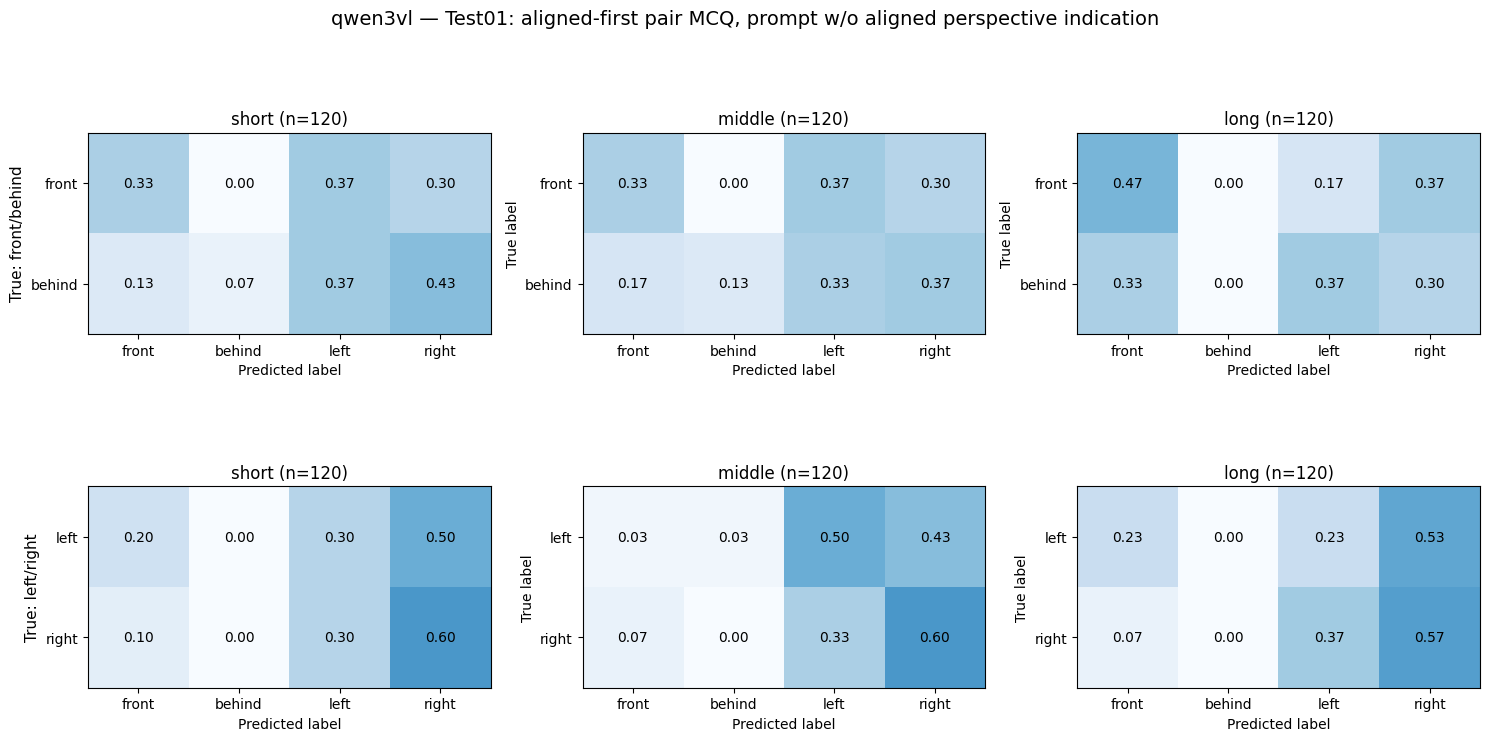

In [3]:
all_dfs_01 = defaultdict(dict) # rerun with a bit more complexed prompt - remove the "aligned perspective indication"

for model in models01:
    print(f"\n===== MODEL: {model} =====")
    dfs = {}

    for length in lengths:
        csv_path = os.path.join(TEST01_DIR, f"pair_mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"  Missing: {csv_path}")
            continue
        df = load_and_prepare_pair(csv_path)
        dfs[length] = df
        all_dfs_01[model][length] = df
        acc = df["is_correct"].mean()
        print(f"  Loaded {length}: {len(df)} rows  |  overall acc = {acc:.3f}")

    if not dfs:
        continue

    # Row 1: true = front/behind; Row 2: true = left/right; columns = short/middle/long
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[0][i].axis("off")
            axes[1][i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length], axes[0][i],
            title=f"{length} (n={len(dfs[length])})",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
        plot_confusion_on_ax(
            dfs[length], axes[1][i],
            title=f"{length} (n={len(dfs[length])})",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )

    axes[0][0].set_ylabel("True: front/behind", fontsize=11)
    axes[1][0].set_ylabel("True: left/right", fontsize=11)
    fig.suptitle(f"{model} — Test01: aligned-first pair MCQ, prompt w/o aligned perspective indication", fontsize=14)
    plt.tight_layout()
    plt.show()


===== MODEL: qwen3vl =====
  Loaded short: 120 rows  |  overall acc = 0.600
  Loaded middle: 120 rows  |  overall acc = 0.575
  Loaded long: 120 rows  |  overall acc = 0.567


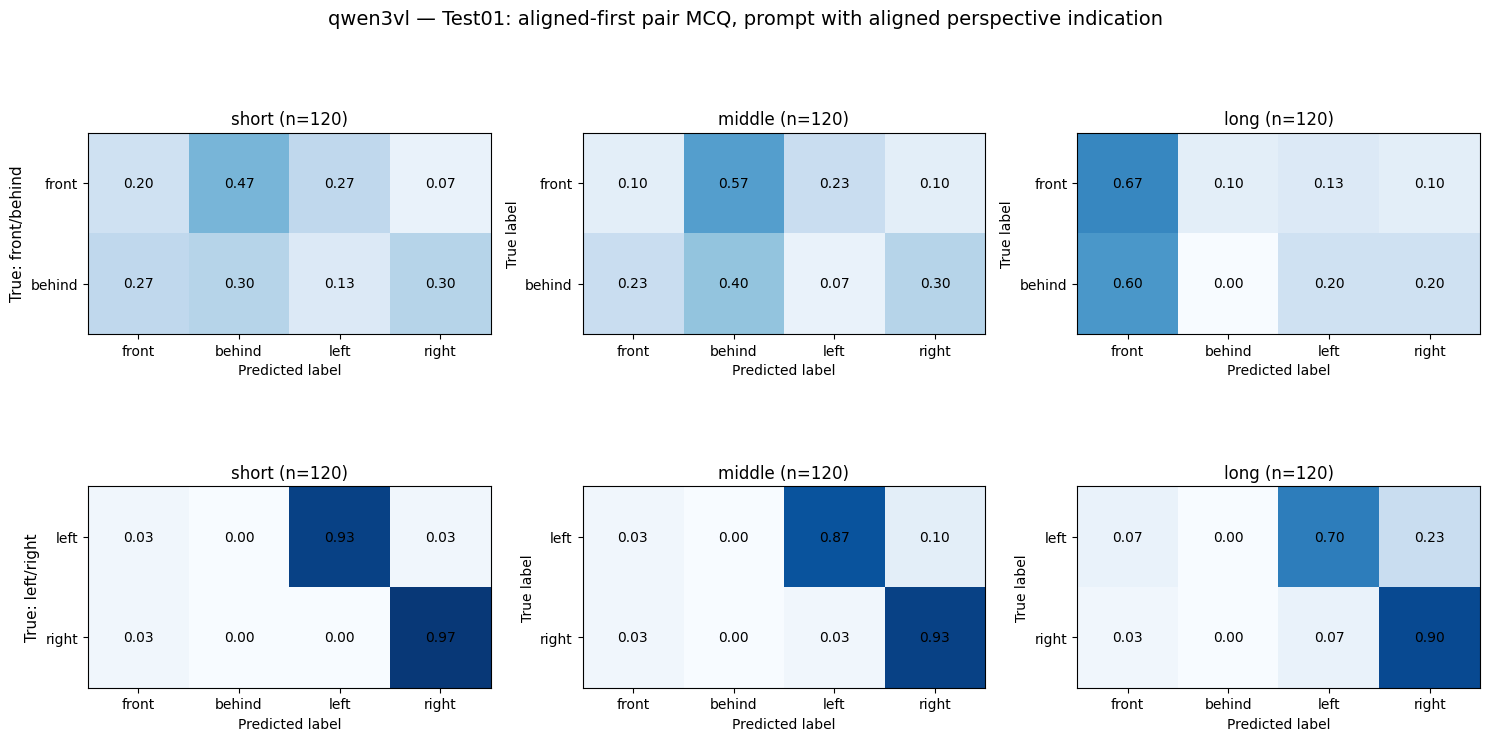

In [4]:
all_dfs_01 = defaultdict(dict)

for model in models01:
    print(f"\n===== MODEL: {model} =====")
    dfs = {}

    for length in lengths:
        csv_path = os.path.join(TEST01_DIR, f"pair_mcq_{length}_{model}_with'aligned'.csv")
        if not os.path.exists(csv_path):
            print(f"  Missing: {csv_path}")
            continue
        df = load_and_prepare_pair(csv_path)
        dfs[length] = df
        all_dfs_01[model][length] = df
        acc = df["is_correct"].mean()
        print(f"  Loaded {length}: {len(df)} rows  |  overall acc = {acc:.3f}")

    if not dfs:
        continue

    # Row 1: true = front/behind; Row 2: true = left/right; columns = short/middle/long
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[0][i].axis("off")
            axes[1][i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length], axes[0][i],
            title=f"{length} (n={len(dfs[length])})",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
        plot_confusion_on_ax(
            dfs[length], axes[1][i],
            title=f"{length} (n={len(dfs[length])})",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )

    axes[0][0].set_ylabel("True: front/behind", fontsize=11)
    axes[1][0].set_ylabel("True: left/right", fontsize=11)
    fig.suptitle(f"{model} — Test01: aligned-first pair MCQ, prompt with aligned perspective indication", fontsize=14)
    plt.tight_layout()
    plt.show()

### 2 — Accuracy by second-image view (cam_view_2)

Since Image 1 is always `cam_back`, the only variable is which view appears as Image 2.

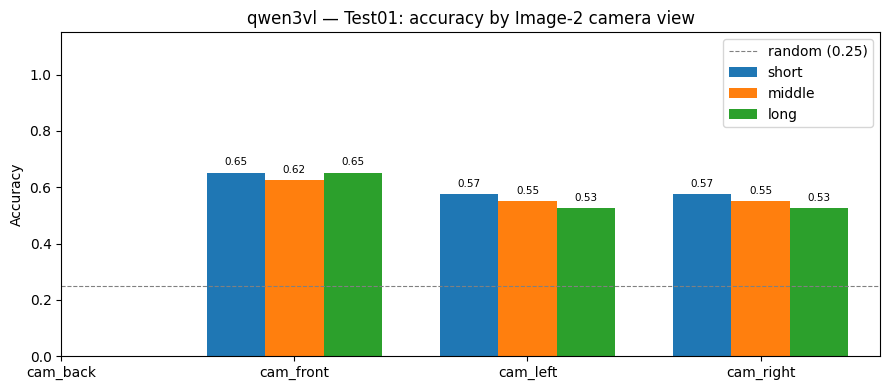

In [5]:
VIEW_SHORT = ["back", "front", "left", "right"]

for model in models01:
    if not all_dfs_01.get(model):
        continue

    available = [l for l in lengths if l in all_dfs_01[model]]
    x = np.arange(len(VIEW_SHORT))
    width = 0.25
    fig, ax = plt.subplots(figsize=(9, 4))

    for k, length in enumerate(available):
        df = all_dfs_01[model][length]
        accs = []
        for v in VIEW_SHORT:
            sub = df[df["view2_short"] == v]
            accs.append(sub["is_correct"].mean() if len(sub) > 0 else np.nan)
        bars = ax.bar(x + (k - len(available)/2 + 0.5) * width, accs, width, label=length)
        for bar, val in zip(bars, accs):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=7.5)

    ax.axhline(0.25, color="gray", linestyle="--", linewidth=0.8, label="random (0.25)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"cam_{v}" for v in VIEW_SHORT])
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{model} — Test01: accuracy by Image-2 camera view")
    ax.legend()
    plt.tight_layout()
    plt.show()

### 3 — Per-relation accuracy table (short / middle / long)

In [6]:
for model in models01:
    if not all_dfs_01.get(model):
        continue
    print(f"\n===== {model} =====")
    rows = []
    for length in lengths:
        if length not in all_dfs_01[model]:
            continue
        df = all_dfs_01[model][length]
        for rel in RELATIONS:
            sub = df[df["correct_relation"] == rel]
            acc = sub["is_correct"].mean() if len(sub) > 0 else np.nan
            rows.append({"length": length, "relation": rel, "n": len(sub), "accuracy": round(acc, 3)})
    tbl = pd.DataFrame(rows).pivot(index="relation", columns="length", values="accuracy")
    display(tbl)


===== qwen3vl =====


length,long,middle,short
relation,,,
behind,0.000,0.400,0.300
front,0.667,0.100,0.200
left,0.700,0.867,0.933
right,0.900,0.933,0.967


---
## Test 02 — POV Image-Choice MCQ

Input: 1 external image + 2 POV images as options (binary A/B).  
Correct = POV camera facing toward the object (relation-dependent).  
Distractor = POV camera facing opposite direction.

In [7]:
TEST02_DIR = "./test02_pov/results"
models02   = ["qwen3vl"]  # ← add more models here as results arrive

### 1 — Confusion matrix (4 relations × correct / distractor)

行 = 物体位置（correct_relation），列 = 模型选了正确答案（cam_pov_front）还是干扰项。

Loaded qwen3vl: 144 rows  |  overall acc = 0.292


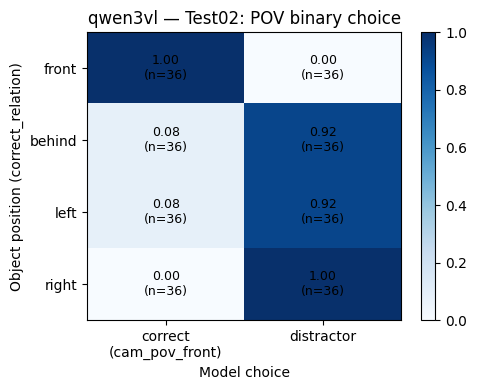

In [8]:
all_dfs_02 = {}

for model in models02:
    csv_path = os.path.join(TEST02_DIR, f"pov_{model}.csv")
    if not os.path.exists(csv_path):
        print(f"Missing: {csv_path}")
        continue
    df = load_and_prepare_pov(csv_path)
    all_dfs_02[model] = df
    acc = df["is_correct"].mean()
    print(f"Loaded {model}: {len(df)} rows  |  overall acc = {acc:.3f}")

    # 4x2 confusion matrix: rows = relation, cols = correct / distractor
    mat = np.zeros((len(RELATIONS), 2))
    for i, rel in enumerate(RELATIONS):
        sub = df[df["correct_relation"] == rel]
        if len(sub) == 0:
            continue
        mat[i, 0] = sub["is_correct"].mean()       # chose cam_pov_front (correct)
        mat[i, 1] = 1 - sub["is_correct"].mean()   # chose distractor

    annot = []
    for i, rel in enumerate(RELATIONS):
        sub = df[df["correct_relation"] == rel]
        n = len(sub)
        annot.append([f"{mat[i,0]:.2f}\n(n={n})", f"{mat[i,1]:.2f}\n(n={n})"])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["correct\n(cam_pov_front)", "distractor"])
    ax.set_yticks(range(len(RELATIONS)))
    ax.set_yticklabels(RELATIONS)
    for i in range(len(RELATIONS)):
        for j in range(2):
            ax.text(j, i, annot[i][j], ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax)
    ax.set_title(f"{model} — Test02: POV binary choice")
    ax.set_xlabel("Model choice")
    ax.set_ylabel("Object position (correct_relation)")
    plt.tight_layout()
    plt.show()

### 2 — Accuracy heatmap: relation × external camera view

In [9]:
# EXT_VIEWS = ["back", "front", "left", "right"]

# for model, df in all_dfs_02.items():
#     mat = np.full((len(RELATIONS), len(EXT_VIEWS)), np.nan)
#     annot = []
#     for i, rel in enumerate(RELATIONS):
#         row_ann = []
#         for j, view in enumerate(EXT_VIEWS):
#             sub = df[(df["correct_relation"] == rel) & (df["cam_view_external_short"] == view)]
#             if len(sub) > 0:
#                 mat[i, j] = sub["is_correct"].mean()
#                 row_ann.append(f"{mat[i,j]:.2f}\n(n={len(sub)})")
#             else:
#                 row_ann.append("")
#         annot.append(row_ann)

#     fig, ax = plt.subplots(figsize=(6, 4))
#     sns.heatmap(
#         mat, ax=ax,
#         annot=annot, fmt="",
#         cmap="RdYlGn", vmin=0, vmax=1,
#         linewidths=0.5,
#         xticklabels=EXT_VIEWS,
#         yticklabels=RELATIONS,
#         annot_kws={"size": 9},
#         cbar=True,
#     )
#     ax.set_xlabel("External camera view")
#     ax.set_ylabel("Correct relation")
#     ax.set_title(f"{model} — Test02: accuracy by relation × external camera")
#     plt.tight_layout()
#     plt.show()

### 3 — Per-relation accuracy table (short / middle / long)

In [10]:
# for model, df in all_dfs_02.items():
#     print(f"\n===== {model} =====")
#     rows = []
#     for rel in RELATIONS:
#         sub = df[df["correct_relation"] == rel]
#         acc = sub["is_correct"].mean() if len(sub) > 0 else np.nan
#         rows.append({"relation": rel, "n": len(sub), "accuracy": round(acc, 3)})
#     rows.append({"relation": "OVERALL", "n": len(df), "accuracy": round(df["is_correct"].mean(), 3)})
#     display(pd.DataFrame(rows).set_index("relation"))

---
## Test 03 — 4-Choice POV MCQ (two objects in scene)

Input: 1 external image + **4** POV images as options (A/B/C/D).  
Scene contains ref_object + third_object at another cardinal position.  
Correct answer: POV camera facing toward ref_object (same logic as Test02).  
Random baseline = 1/3 ≈ 0.33 (3-choice).

In [11]:
TEST03_DIR = "./test03_pov_four/results"
models03   = ["qwen3vl"]  # ← add more models here as results arrive

In [12]:
import ast

def load_and_prepare_pov4(csv_path):
    df = pd.read_csv(csv_path)
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower()
    df["correct_relation"] = df["correct_relation"].map(RELATION_MAP).fillna(df["correct_relation"])
    df["third_object_relation"] = df["third_object_relation"].astype(str).str.strip().str.lower()
    df["third_object_relation"] = df["third_object_relation"].map(RELATION_MAP).fillna(df["third_object_relation"])
    df["is_correct"] = df["correct"].astype(str).str.lower().isin(["true", "1"])
    df["cam_view_external_short"] = df["cam_view_external"].str.replace("cam_", "", regex=False)

    def get_pred_choice(row):
        try:
            cam_order = ast.literal_eval(row["cam_order"])
        except Exception:
            return None
        idx = {"A": 0, "B": 1, "C": 2}.get(str(row["pred_letter"]).strip())
        if idx is None or idx >= len(cam_order):
            return None
        pred_cam = cam_order[idx]
        if pred_cam == str(row["cam_correct"]).strip():
            return "correct"
        elif pred_cam == str(row["cam_dist1"]).strip():
            return "dist_thirdobj"
        elif pred_cam == str(row["cam_dist2"]).strip():
            return "dist_secondobj"
        return None

    df["pred_choice"] = df.apply(get_pred_choice, axis=1)
    return df

all_dfs_03 = {}

for model in models03:
    csv_path = os.path.join(TEST03_DIR, f"pov4_{model}.csv")
    if not os.path.exists(csv_path):
        print(f"Missing: {csv_path}")
        continue
    df = load_and_prepare_pov4(csv_path)
    all_dfs_03[model] = df
    acc = df["is_correct"].mean()
    print(f"Loaded {model}: {len(df)} rows  |  overall acc = {acc:.3f}  |  random baseline = 1/3 ≈ 0.33")

Loaded qwen3vl: 432 rows  |  overall acc = 0.306  |  random baseline = 1/3 ≈ 0.33


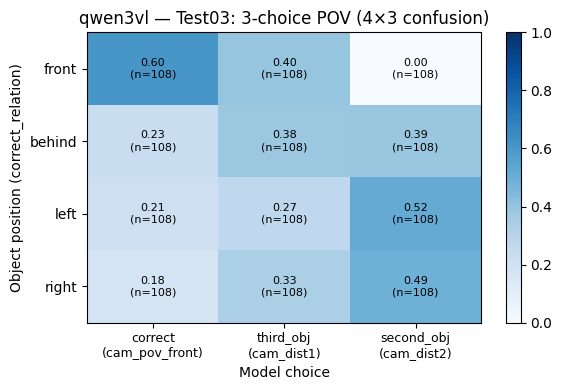

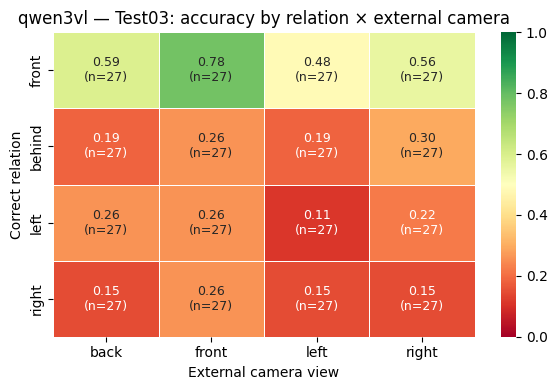

,n,correct,dist_thirdobj,dist_secondobj
relation,,,,
front,108,0.602,0.398,0.000
behind,108,0.231,0.380,0.389
left,108,0.213,0.269,0.519
right,108,0.176,0.333,0.491
OVERALL,432,0.306,0.345,0.350


In [13]:
CHOICE_COLS  = ["correct", "dist_thirdobj", "dist_secondobj"]
CHOICE_LABELS = ["correct\n(cam_pov_front)", "third_obj\n(cam_dist1)", "second_obj\n(cam_dist2)"]
EXT_VIEWS = ["back", "front", "left", "right"]

for model, df in all_dfs_03.items():
    if "pred_choice" not in df.columns:
        print(f"ERROR: pred_choice missing for {model}. Re-run the loading cell first.")
        continue

    # ── 1: 4×3 confusion matrix ───────────────────────────────────────────
    mat = np.zeros((len(RELATIONS), 3))
    annot = []
    for i, rel in enumerate(RELATIONS):
        sub = df[df["correct_relation"] == rel]
        n = len(sub)
        row_ann = []
        for j, col in enumerate(CHOICE_COLS):
            frac = (sub["pred_choice"] == col).sum() / n if n > 0 else 0
            mat[i, j] = frac
            row_ann.append(f"{frac:.2f}\n(n={n})")
        annot.append(row_ann)

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(3))
    ax.set_xticklabels(CHOICE_LABELS, fontsize=9)
    ax.set_yticks(range(len(RELATIONS)))
    ax.set_yticklabels(RELATIONS)
    for i in range(len(RELATIONS)):
        for j in range(3):
            ax.text(j, i, annot[i][j], ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax)
    ax.set_title(f"{model} — Test03: 3-choice POV (4×3 confusion)")
    ax.set_xlabel("Model choice")
    ax.set_ylabel("Object position (correct_relation)")
    plt.tight_layout()
    plt.show()

    # ── 2: heatmap — relation × external camera view (accuracy) ──────────
    mat2 = np.full((len(RELATIONS), len(EXT_VIEWS)), np.nan)
    annot2 = []
    for i, rel in enumerate(RELATIONS):
        row_ann = []
        for j, view in enumerate(EXT_VIEWS):
            sub = df[(df["correct_relation"] == rel) & (df["cam_view_external_short"] == view)]
            if len(sub) > 0:
                mat2[i, j] = sub["is_correct"].mean()
                row_ann.append(f"{mat2[i,j]:.2f}\n(n={len(sub)})")
            else:
                row_ann.append("")
        annot2.append(row_ann)

    fig2, ax2 = plt.subplots(figsize=(6, 4))
    sns.heatmap(mat2, ax=ax2, annot=annot2, fmt="",
                cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5,
                xticklabels=EXT_VIEWS, yticklabels=RELATIONS,
                annot_kws={"size": 9}, cbar=True)
    ax2.set_xlabel("External camera view")
    ax2.set_ylabel("Correct relation")
    ax2.set_title(f"{model} — Test03: accuracy by relation × external camera")
    plt.tight_layout()
    plt.show()

    # ── 3: per-relation table ─────────────────────────────────────────────
    rows = []
    for rel in RELATIONS:
        sub = df[df["correct_relation"] == rel]
        n = len(sub)
        rows.append({
            "relation":     rel,
            "n":            n,
            "correct":      round((sub["pred_choice"] == "correct").sum() / n, 3) if n > 0 else np.nan,
            "dist_thirdobj":  round((sub["pred_choice"] == "dist_thirdobj").sum() / n, 3) if n > 0 else np.nan,
            "dist_secondobj": round((sub["pred_choice"] == "dist_secondobj").sum() / n, 3) if n > 0 else np.nan,
        })
    rows.append({
        "relation": "OVERALL", "n": len(df),
        "correct":      round(df["is_correct"].mean(), 3),
        "dist_thirdobj":  round((df["pred_choice"] == "dist_thirdobj").mean(), 3),
        "dist_secondobj": round((df["pred_choice"] == "dist_secondobj").mean(), 3),
    })
    display(pd.DataFrame(rows).set_index("relation"))